# Statistical Analysis
**Dependent Variable:** College Going Rate (CGR)  
**Data Source:** California Department of Education (2024–2025)  
**Sample:** California Public High Schools

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
import warnings
warnings.filterwarnings('ignore')

## Data Loading & Preparation

In [2]:
# Load and filter to public high schools
raw = pd.read_csv('../cleaned_data/final_merged_dataset.csv').drop(columns=['Unnamed: 0'])
df = raw[raw['School Type'] == 'High Schools (Public)'].copy()
for col in ['Charter School', 'DASS']:
    df[col] = df[col].str.strip()

# Rename columns for statsmodels formula API
df = df.rename(columns={
    'College Going Rate - Total (12 Months)': 'CGR',
    'ChronicAbsenteeismRate': 'ChronicAbsenteeism',
    'Percent Eligible FRPM': 'FRPM',
    'Homeless Student Enrollment (Rate)': 'HomelessRate',
    'Suspension Rate': 'SuspensionRate',
    'Expulsion Rate': 'ExpulsionRate',
    'Stability Rate (percent)': 'StabilityRate',
    'Percentage Standard Met and Above': 'PctStdMet',
    'Students Tested with Scores (Rate)': 'PctTested',
    "Met UC/CSU Grad Req's (Rate)": 'UCCSUReqMet',
    'Dropout (Rate)': 'DropoutRate',
    'Charter School': 'CharterSchool',
    'STU_TCH_RATIO': 'StuTeacherRatio',
    'CumulativeEnrollment': 'Enrollment',
})

# Create binary categorical variables for t-tests (median splits)
df['HighPoverty'] = np.where(df['FRPM'] >= df['FRPM'].median(), 'High', 'Low')
df['HighAbsenteeism'] = np.where(
    df['ChronicAbsenteeism'] >= df['ChronicAbsenteeism'].median(), 'High', 'Low'
)

# Create complete-case subset for regression
# (ensures all models use the same observations)
reg_vars = ['CGR', 'FRPM', 'ChronicAbsenteeism', 'StabilityRate', 'PctStdMet',
            'UCCSUReqMet', 'SuspensionRate', 'HomelessRate', 'StuTeacherRatio',
            'DropoutRate', 'Enrollment', 'CharterSchool']
df_complete = df[reg_vars].dropna().copy()

print(f'Total schools: {len(df)}')
print(f'Schools with CGR: {df["CGR"].notna().sum()}')
print(f'Complete cases for regression: {len(df_complete)}')
print(f'\nCGR Summary:')
df['CGR'].describe()

Total schools: 935
Schools with CGR: 923
Complete cases for regression: 890

CGR Summary:


count    923.000000
mean      68.290791
std       13.936560
min        9.600000
25%       58.050000
50%       69.400000
75%       79.300000
max       96.500000
Name: CGR, dtype: float64

## T-Tests on Key Individual Variables

Before running the regression, perform independent-samples t-tests to examine simple
bivariate relationships between key categorical predictors and CGR. These tests show whether group means differ significantly.

### T-Test 1: Charter School (Yes vs No)

In [3]:
group_charter = df[df['CharterSchool'] == 'Yes']['CGR'].dropna()
group_noncharter = df[df['CharterSchool'] == 'No']['CGR'].dropna()

t_stat, p_val = stats.ttest_ind(group_charter, group_noncharter)

print(f'Charter schools:     n = {len(group_charter)}, mean CGR = {group_charter.mean():.2f}')
print(f'Non-charter schools: n = {len(group_noncharter)}, mean CGR = {group_noncharter.mean():.2f}')
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_val:.4f}')
print(f'Significant (p < 0.05)? {"Yes" if p_val < 0.05 else "No"}')

Charter schools:     n = 105, mean CGR = 67.50
Non-charter schools: n = 818, mean CGR = 68.39
T-statistic: -0.6196
P-value: 0.5356
Significant (p < 0.05)? No


### T-Test 2: Poverty Level (High vs Low FRPM, median split)

In [4]:
group_highpov = df[df['HighPoverty'] == 'High']['CGR'].dropna()
group_lowpov = df[df['HighPoverty'] == 'Low']['CGR'].dropna()

t_stat, p_val = stats.ttest_ind(group_highpov, group_lowpov)

print(f'High Poverty (FRPM >= median): n = {len(group_highpov)}, mean CGR = {group_highpov.mean():.2f}')
print(f'Low Poverty (FRPM < median):   n = {len(group_lowpov)}, mean CGR = {group_lowpov.mean():.2f}')
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_val:.4f}')
print(f'Significant (p < 0.05)? {"Yes" if p_val < 0.05 else "No"}')

High Poverty (FRPM >= median): n = 464, mean CGR = 61.59
Low Poverty (FRPM < median):   n = 459, mean CGR = 75.06
T-statistic: -16.7658
P-value: 0.0000
Significant (p < 0.05)? Yes


### T-Test 3: Chronic Absenteeism (High vs Low, median split)

In [5]:
group_highabs = df[df['HighAbsenteeism'] == 'High']['CGR'].dropna()
group_lowabs = df[df['HighAbsenteeism'] == 'Low']['CGR'].dropna()

t_stat, p_val = stats.ttest_ind(group_highabs, group_lowabs)

print(f'High Absenteeism (>= median): n = {len(group_highabs)}, mean CGR = {group_highabs.mean():.2f}')
print(f'Low Absenteeism (< median):   n = {len(group_lowabs)}, mean CGR = {group_lowabs.mean():.2f}')
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_val:.4f}')
print(f'Significant (p < 0.05)? {"Yes" if p_val < 0.05 else "No"}')

High Absenteeism (>= median): n = 462, mean CGR = 61.57
Low Absenteeism (< median):   n = 461, mean CGR = 75.02
T-statistic: -16.7368
P-value: 0.0000
Significant (p < 0.05)? Yes


### T-Test Visualizations

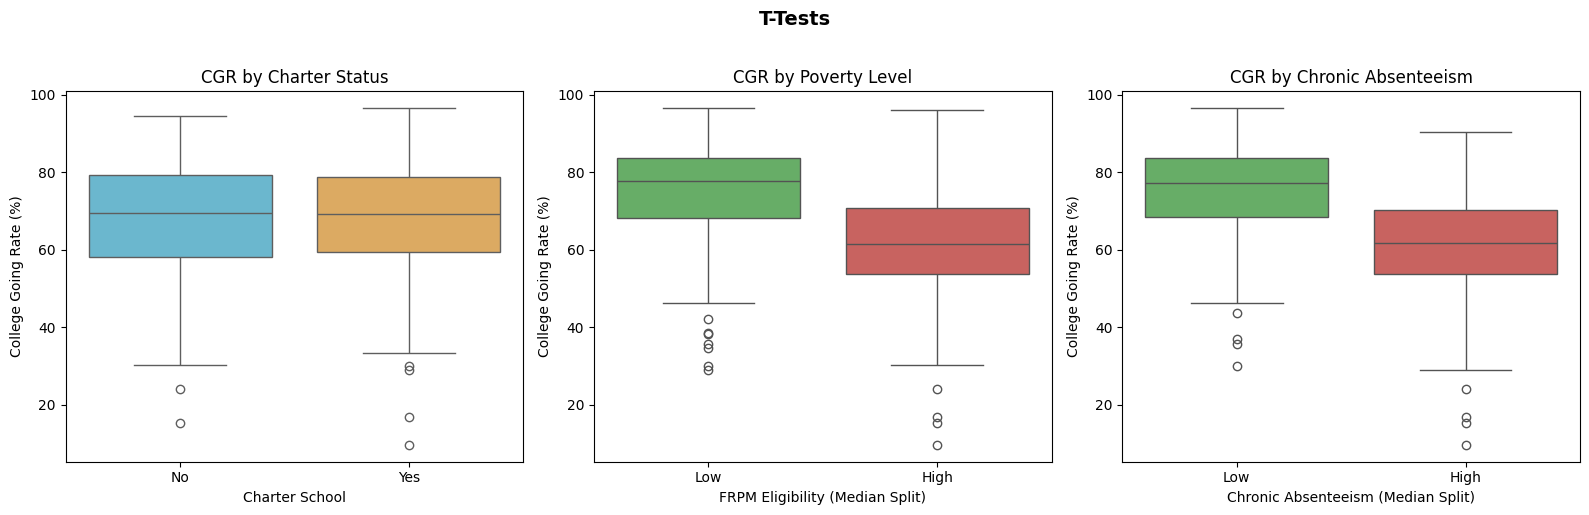

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df.dropna(subset=['CGR']), x='CharterSchool', y='CGR',
            palette={'Yes': '#f0ad4e', 'No': '#5bc0de'}, ax=axes[0])
axes[0].set_title('CGR by Charter Status')
axes[0].set_xlabel('Charter School')
axes[0].set_ylabel('College Going Rate (%)')

sns.boxplot(data=df.dropna(subset=['CGR']), x='HighPoverty', y='CGR',
            order=['Low', 'High'], palette={'High': '#d9534f', 'Low': '#5cb85c'}, ax=axes[1])
axes[1].set_title('CGR by Poverty Level')
axes[1].set_xlabel('FRPM Eligibility (Median Split)')
axes[1].set_ylabel('College Going Rate (%)')

sns.boxplot(data=df.dropna(subset=['CGR']), x='HighAbsenteeism', y='CGR',
            order=['Low', 'High'], palette={'High': '#d9534f', 'Low': '#5cb85c'}, ax=axes[2])
axes[2].set_title('CGR by Chronic Absenteeism')
axes[2].set_xlabel('Chronic Absenteeism (Median Split)')
axes[2].set_ylabel('College Going Rate (%)')

plt.suptitle('T-Tests', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Multiple Linear Regression (Primary Analysis)

We fit a full multiple linear regression using `statsmodels.formula.api` (`smf`). The model
predicts CGR using socioeconomic indicators, academic achievement measures, school climate
variables, and charter school status.

**Formula:**
```
CGR ~ FRPM + ChronicAbsenteeism + StabilityRate + PctStdMet +
      UCCSUReqMet + SuspensionRate + HomelessRate + StuTeacherRatio +
      DropoutRate + Enrollment + C(CharterSchool)
```

In [7]:
formula = (
    'CGR ~ FRPM + ChronicAbsenteeism + StabilityRate + PctStdMet + '
    'UCCSUReqMet + SuspensionRate + HomelessRate + StuTeacherRatio + '
    'DropoutRate + Enrollment + C(CharterSchool)'
)

model = smf.ols(formula, data=df_complete).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    CGR   R-squared:                       0.575
Model:                            OLS   Adj. R-squared:                  0.569
Method:                 Least Squares   F-statistic:                     107.9
Date:                Thu, 12 Mar 2026   Prob (F-statistic):          1.13e-154
Time:                        05:38:30   Log-Likelihood:                -3222.8
No. Observations:                 890   AIC:                             6470.
Df Residuals:                     878   BIC:                             6527.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  24.1224      6.715      3.592      0.000      10.942      37.303
C(CharterSchool)[T.Yes]    -1.6736      1.161     -1.441      0.150      -3.953       0.606
FRPM                      -14.9149      1.779     -8.383      0.000     -18.407     -11.423
ChronicAbsenteeism         -0.1334      0.043     -3.089      0.002      -0.218      -0.049
StabilityRate               0.4478      0.063      7.149      0.000       0.325       0.571
PctStdMet                   0.1720      0.032      5.396      0.000       0.109       0.235
UCCSUReqMet                 0.1478      0.021      7.010      0.000       0.106       0.189
SuspensionRate             23.5537      7.654      3.077      0.002       8.531      38.576
HomelessRate               13.6414      6.985      1.953      0.051      -0.067      27.350
StuTeacherRatio             0.0089      0.126      0.071      0.944      -0.238       0.256
DropoutRate                -0.0103      0.074     -0.140      0.889      -0.155       0.135
Enrollment                  0.0010      0.000      2.055      0.040    4.46e-05       0.002
==============================================================================
Omnibus:                       32.802   Durbin-Watson:                   1.189
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               46.778
Skew:                          -0.342   Prob(JB):                     6.95e-11
Kurtosis:                       3.891   Cond. No.                     4.36e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.36e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [8]:
print(f'N (observations):  {int(model.nobs)}')
print(f'F-statistic:       F({int(model.df_model)}, {int(model.df_resid)}) = {model.fvalue:.4f}')
print(f'F p-value:         {model.f_pvalue:.4e}')
print(f'R²:                {model.rsquared:.4f}')
print(f'Adjusted R²:       {model.rsquared_adj:.4f}')

print('\nSignificant predictors (p < 0.05):')
for name, pval in model.pvalues.items():
    if pval < 0.05 and name != 'Intercept':
        coef = model.params[name]
        print(f'  {"+" if coef > 0 else "-"} {name}: β = {coef:.4f}, p = {pval:.4e}')

print('\nNon-significant predictors (p >= 0.05):')
for name, pval in model.pvalues.items():
    if pval >= 0.05 and name != 'Intercept':
        print(f'  {name}: β = {model.params[name]:.4f}, p = {pval:.4f}')

print('\nINTERPRETATION: Each β represents the change in CGR (percentage points)')
print('for a one-unit increase in that predictor, holding all others constant.')

N (observations):  890
F-statistic:       F(11, 878) = 107.9075
F p-value:         1.1258e-154
R²:                0.5748
Adjusted R²:       0.5695

Significant predictors (p < 0.05):
  - FRPM: β = -14.9149, p = 2.0361e-16
  - ChronicAbsenteeism: β = -0.1334, p = 2.0711e-03
  + StabilityRate: β = 0.4478, p = 1.8443e-12
  + PctStdMet: β = 0.1720, p = 8.7759e-08
  + UCCSUReqMet: β = 0.1478, p = 4.7611e-12
  + SuspensionRate: β = 23.5537, p = 2.1538e-03
  + Enrollment: β = 0.0010, p = 4.0210e-02

Non-significant predictors (p >= 0.05):
  C(CharterSchool)[T.Yes]: β = -1.6736, p = 0.1500
  HomelessRate: β = 13.6414, p = 0.0511
  StuTeacherRatio: β = 0.0089, p = 0.9437
  DropoutRate: β = -0.0103, p = 0.8886

INTERPRETATION: Each β represents the change in CGR (percentage points)
for a one-unit increase in that predictor, holding all others constant.


### Multicollinearity

**SuspensionRate** and **HomelessRate** have *positive* regression coefficients, even though their bivariate correlations with CGR are *negative*. This is likely a consequence of **multicollinearity**: SuspensionRate, HomelessRate, and FRPM (poverty) are all highly correlated with each other. When all three are included in the model simultaneously, the coefficient of each variable reflects its relationship with CGR *after controlling for the others*, which can differ substantially from its raw bivariate correlation.

This does **not** mean that more suspensions or homelessness *cause* higher CGR. It means that among schools with similar poverty levels, the remaining variation in these variables
relates to CGR differently than the raw correlation suggests. When there is multicollinearity, individual coefficients become difficult to interpret in isolation.

## ANOVA F-Test

### Overall F-Test
The ANOVA F-test tests:
- **H₀:** All β coefficients = 0 (none of the predictors explain variation in CGR)
- **H₁:** At least one predictor significantly explains variation in CGR

In [9]:
print(f'Overall ANOVA F-Test:')
print(f'  F({int(model.df_model)}, {int(model.df_resid)}) = {model.fvalue:.4f}')
print(f'  P-value = {model.f_pvalue:.4e}')

if model.f_pvalue < 0.05:
    print(f'\nREJECT H₀: The model as a whole significantly explains')
    print(f'variation in College Going Rate (p < 0.05).')
else:
    print(f'\nFAIL TO REJECT H₀.')

Overall ANOVA F-Test:
  F(11, 878) = 107.9075
  P-value = 1.1258e-154

REJECT H₀: The model as a whole significantly explains
variation in College Going Rate (p < 0.05).


### Nested Model Comparison

Test whether the academic and school climate variables significantly improve the model beyond what socioeconomic factors alone can explain.

- **Reduced model:** `CGR ~ FRPM + HomelessRate + Enrollment` (socioeconomic only)
- **Full model:** All predictors

In [10]:
reduced_formula = 'CGR ~ FRPM + HomelessRate + Enrollment'

reduced_model = smf.ols(reduced_formula, data=df_complete).fit()
full_model = model

anova_result = anova_lm(reduced_model, full_model)
print(anova_result)

anova_p = anova_result['Pr(>F)'].iloc[1]
print(f'\nReduced model R²: {reduced_model.rsquared:.4f}')
print(f'Full model R²:    {full_model.rsquared:.4f}')
print(f'R² improvement:   {full_model.rsquared - reduced_model.rsquared:.4f}')

if anova_p < 0.05:
    print(f'\nThe additional predictors significantly improve the model (p = {anova_p:.4e}).')
    print(f'They explain variation in CGR beyond what socioeconomic factors alone capture.')
else:
    print(f'\nThe additional predictors do NOT significantly improve the model (p = {anova_p:.4f}).')

   df_resid            ssr  df_diff       ss_diff          F        Pr(>F)
0     886.0  108830.453586      0.0           NaN        NaN           NaN
1     878.0   72807.549843      8.0  36022.903743  54.300875  1.209621e-71

Reduced model R²: 0.3644
Full model R²:    0.5748
R² improvement:   0.2104

The additional predictors significantly improve the model (p = 1.2096e-71).
They explain variation in CGR beyond what socioeconomic factors alone capture.


## Regression Diagnostics

1. **Residual Plot** — checks for homoscedasticity (constant variance of residuals)
2. **Q-Q Plot** — checks for normality of residuals

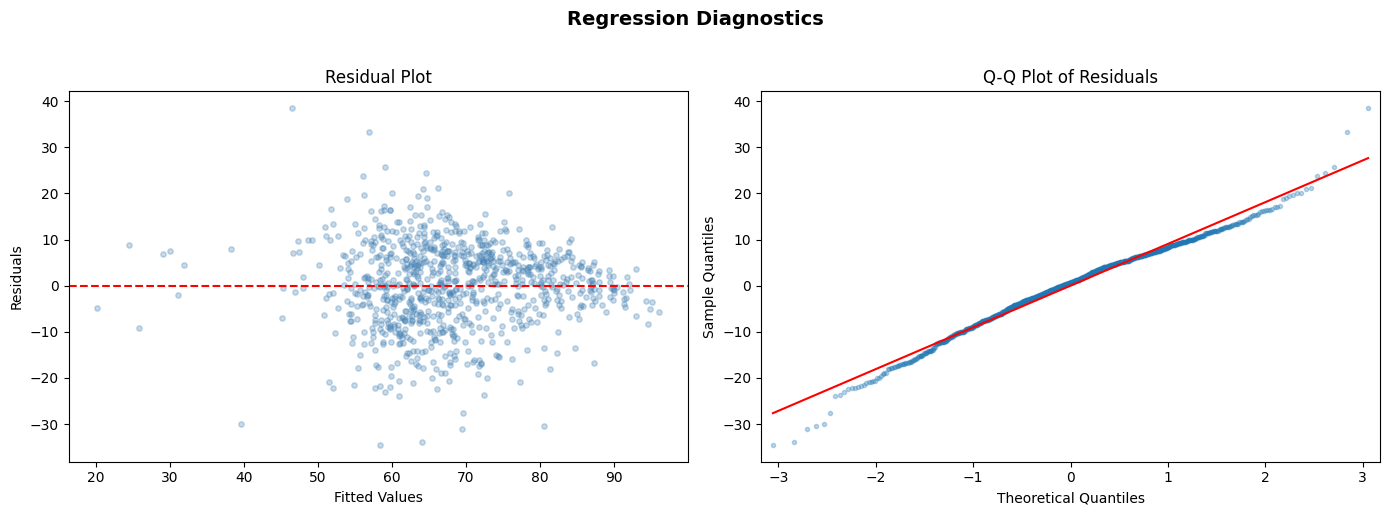

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual Plot
ax = axes[0]
ax.scatter(model.fittedvalues, model.resid, alpha=0.3, s=15, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residual Plot')

# Q-Q Plot
ax = axes[1]
sm.qqplot(model.resid, line='s', ax=ax, markersize=3, alpha=0.3, color='steelblue')
ax.set_title('Q-Q Plot of Residuals')

plt.suptitle('Regression Diagnostics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Results

### T-Test Results Table

In [12]:
ttest_data = [
    {'Variable': 'Charter School (Yes vs No)',
     'Group 1 Mean CGR': df[df['CharterSchool']=='Yes']['CGR'].dropna().mean(),
     'Group 2 Mean CGR': df[df['CharterSchool']=='No']['CGR'].dropna().mean(),
     'T-Statistic': stats.ttest_ind(df[df['CharterSchool']=='Yes']['CGR'].dropna(),
                                     df[df['CharterSchool']=='No']['CGR'].dropna())[0],
     'P-Value': stats.ttest_ind(df[df['CharterSchool']=='Yes']['CGR'].dropna(),
                                 df[df['CharterSchool']=='No']['CGR'].dropna())[1]},
    {'Variable': 'Poverty Level (High vs Low FRPM)',
     'Group 1 Mean CGR': df[df['HighPoverty']=='High']['CGR'].dropna().mean(),
     'Group 2 Mean CGR': df[df['HighPoverty']=='Low']['CGR'].dropna().mean(),
     'T-Statistic': stats.ttest_ind(df[df['HighPoverty']=='High']['CGR'].dropna(),
                                     df[df['HighPoverty']=='Low']['CGR'].dropna())[0],
     'P-Value': stats.ttest_ind(df[df['HighPoverty']=='High']['CGR'].dropna(),
                                 df[df['HighPoverty']=='Low']['CGR'].dropna())[1]},
    {'Variable': 'Chronic Absenteeism (High vs Low)',
     'Group 1 Mean CGR': df[df['HighAbsenteeism']=='High']['CGR'].dropna().mean(),
     'Group 2 Mean CGR': df[df['HighAbsenteeism']=='Low']['CGR'].dropna().mean(),
     'T-Statistic': stats.ttest_ind(df[df['HighAbsenteeism']=='High']['CGR'].dropna(),
                                     df[df['HighAbsenteeism']=='Low']['CGR'].dropna())[0],
     'P-Value': stats.ttest_ind(df[df['HighAbsenteeism']=='High']['CGR'].dropna(),
                                 df[df['HighAbsenteeism']=='Low']['CGR'].dropna())[1]},
]
ttest_df = pd.DataFrame(ttest_data)
ttest_df['Significant?'] = ttest_df['P-Value'].apply(lambda p: 'Yes' if p < 0.05 else 'No')
ttest_df

,Variable,Group 1 Mean CGR,Group 2 Mean CGR,T-Statistic,P-Value,Significant?
0,Charter School (Yes vs No),67.497143,68.392665,-0.619649,5.356419e-01,No
1,Poverty Level (High vs Low FRPM),61.591595,75.062963,-16.765785,2.910906e-55,Yes
2,Chronic Absenteeism (High vs Low),61.571429,75.024729,-16.736762,4.230960e-55,Yes


### Regression Results Table

In [13]:
reg_table = pd.DataFrame({
    'Predictor': model.params.index,
    'β Coefficient': model.params.values.round(4),
    'Std Error': model.bse.values.round(4),
    't-Statistic': model.tvalues.values.round(4),
    'P-Value': model.pvalues.values,
    '95% CI Low': model.conf_int()[0].values.round(4),
    '95% CI High': model.conf_int()[1].values.round(4),
})
reg_table

,Predictor,β Coefficient,Std Error,t-Statistic,P-Value,95% CI Low,95% CI High
0,Intercept,24.1224,6.7155,3.5920,3.463197e-04,10.9421,37.3027
1,C(CharterSchool)[T.Yes],-1.6736,1.1615,-1.4409,1.499746e-01,-3.9532,0.6061
2,FRPM,-14.9149,1.7792,-8.3831,2.036119e-16,-18.4069,-11.4230
3,ChronicAbsenteeism,-0.1334,0.0432,-3.0891,2.071109e-03,-0.2181,-0.0486
4,StabilityRate,0.4478,0.0626,7.1486,1.844337e-12,0.3249,0.5707
5,PctStdMet,0.1720,0.0319,5.3959,8.775868e-08,0.1095,0.2346
6,UCCSUReqMet,0.1478,0.0211,7.0097,4.761133e-12,0.1064,0.1892
7,SuspensionRate,23.5537,7.6540,3.0773,2.153800e-03,8.5313,38.5760
8,HomelessRate,13.6414,6.9847,1.9530,5.113112e-02,-0.0672,27.3500
9,StuTeacherRatio,0.0089,0.1258,0.0707,9.436603e-01,-0.2381,0.2559


In [14]:
print(f'N = {int(model.nobs)}')
print(f'F-statistic = F({int(model.df_model)}, {int(model.df_resid)}) = {model.fvalue:.4f}')
print(f'F p-value = {model.f_pvalue:.4e}')
print(f'R² = {model.rsquared:.4f}')
print(f'Adjusted R² = {model.rsquared_adj:.4f}')

N = 890
F-statistic = F(11, 878) = 107.9075
F p-value = 1.1258e-154
R² = 0.5748
Adjusted R² = 0.5695


### Interpretation

In [15]:
print(f'The model explains {model.rsquared*100:.1f}% of the variation in College Going Rate')
print(f'across {int(model.nobs)} California public high schools (Adj. R² = {model.rsquared_adj:.4f}).\n')
print(f'The overall F-test is highly significant (F = {model.fvalue:.2f}, p < 0.0001),')
print(f'meaning the predictors collectively explain variation in CGR.\n')

print('Significant predictors and interpretations:')
for name in model.params.index:
    if name == 'Intercept': continue
    coef = model.params[name]
    pval = model.pvalues[name]
    if pval < 0.05:
        if 'C(' in name:
            print(f'  • {name}: Associated with {abs(coef):.2f} pp '
                  f'{"higher" if coef > 0 else "lower"} CGR (p = {pval:.4f})')
        else:
            print(f'  • {name}: A one-unit increase is associated with a '
                  f'{coef:+.4f} pp change in CGR (p = {pval:.4e})')

The model explains 57.5% of the variation in College Going Rate
across 890 California public high schools (Adj. R² = 0.5695).

The overall F-test is highly significant (F = 107.91, p < 0.0001),
meaning the predictors collectively explain variation in CGR.

Significant predictors and interpretations:
  • FRPM: A one-unit increase is associated with a -14.9149 pp change in CGR (p = 2.0361e-16)
  • ChronicAbsenteeism: A one-unit increase is associated with a -0.1334 pp change in CGR (p = 2.0711e-03)
  • StabilityRate: A one-unit increase is associated with a +0.4478 pp change in CGR (p = 1.8443e-12)
  • PctStdMet: A one-unit increase is associated with a +0.1720 pp change in CGR (p = 8.7759e-08)
  • UCCSUReqMet: A one-unit increase is associated with a +0.1478 pp change in CGR (p = 4.7611e-12)
  • SuspensionRate: A one-unit increase is associated with a +23.5537 pp change in CGR (p = 2.1538e-03)
  • Enrollment: A one-unit increase is associated with a +0.0010 pp change in CGR (p = 4.0210e